# Filtered Probes Visualization

Plots the `reproducibility_filtered_probes.json` IP list on a world map.
Coordinates are joined in from `reproducibility_probes.json` via `address_v4`.

In [12]:
# === Parameters (tagged) ===
FILTERED_PROBES_PATH = "datasets/reproducibility_datasets/generated/reproducibility_filtered_probes.json"
PROBES_PATH = "datasets/reproducibility_datasets/atlas/reproducibility_probes.json"
ANCHORS_PATH = "datasets/reproducibility_datasets/atlas/reproducibility_anchors.json"

In [13]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
print(f"repo root: {ROOT}")

with open(ROOT / FILTERED_PROBES_PATH) as fh:
    filtered_ips = set(json.load(fh))
print(f"filtered probes: {len(filtered_ips)} IPs")

with open(ROOT / PROBES_PATH) as fh:
    raw_probes = json.load(fh)

rows = []
for e in raw_probes:
    ip = e.get("address_v4")
    if ip not in filtered_ips:
        continue
    geom = (e.get("geometry") or {}).get("coordinates")
    if not geom or len(geom) < 2:
        continue
    rows.append({
        "ip": ip,
        "lat": float(geom[1]),
        "lon": float(geom[0]),
        "country": e.get("country_code"),
        "asn": e.get("asn_v4"),
    })
df = pd.DataFrame(rows)
print(f"matched {len(df)}/{len(filtered_ips)} filtered probes to metadata")

repo root: /home/nuwinslab/workspace/atnt/cbg-framework
filtered probes: 105 IPs
matched 79/105 filtered probes to metadata


## World map: filtered probes

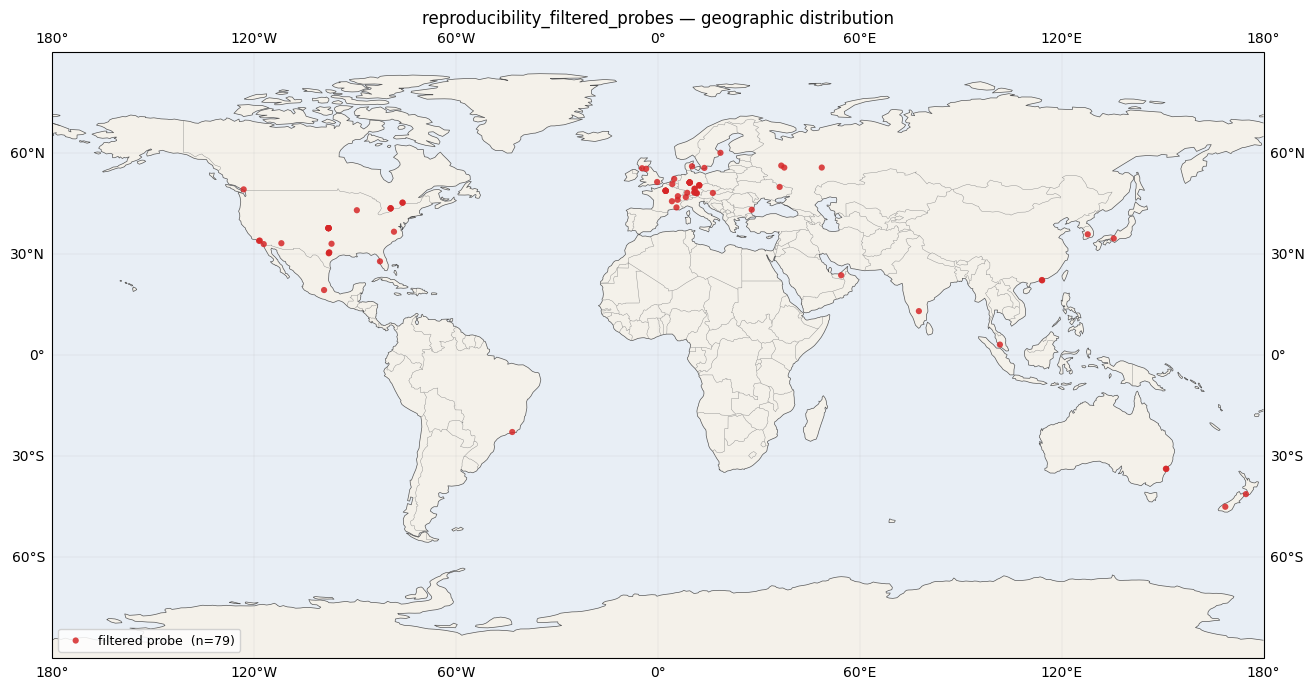

In [14]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="#f4f1ea")
ax.add_feature(cfeature.OCEAN, facecolor="#e8eef5")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="#555")
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="#888")
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
ax.scatter(df["lon"], df["lat"], s=20, c="#d62728", alpha=0.85,
           edgecolors="none", label=f"filtered probe  (n={len(df)})",
           transform=ccrs.PlateCarree(), zorder=3)
ax.set_title("reproducibility_filtered_probes — geographic distribution")
ax.legend(loc="lower left", fontsize=9, framealpha=0.85)
plt.tight_layout()
plt.show()

## World map: all probes (filtered highlighted)

all probes with coords: 12129


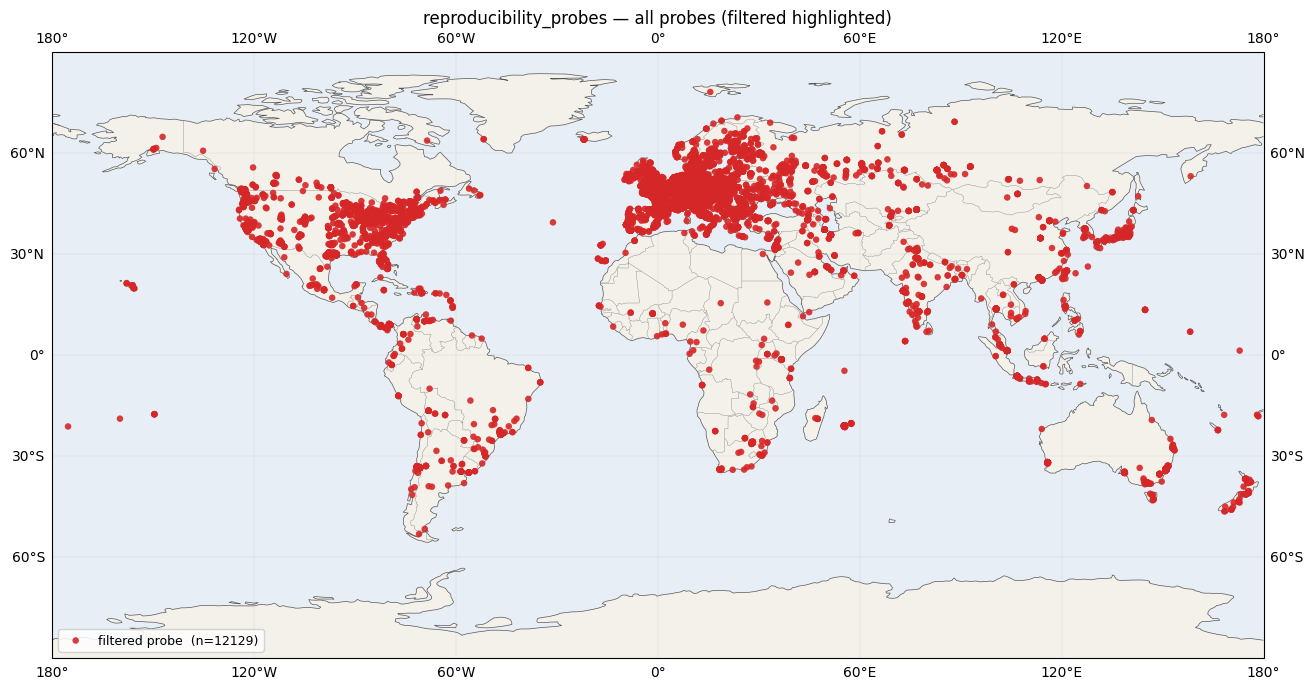

In [15]:
all_rows = []
for e in raw_probes:
    geom = (e.get("geometry") or {}).get("coordinates")
    if not geom or len(geom) < 2:
        continue
    all_rows.append({
        "ip": e.get("address_v4"),
        "lat": float(geom[1]),
        "lon": float(geom[0]),
        "country": e.get("country_code"),
        "asn": e.get("asn_v4"),
    })
all_df = pd.DataFrame(all_rows)
print(f"all probes with coords: {len(all_df)}")

fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="#f4f1ea")
ax.add_feature(cfeature.OCEAN, facecolor="#e8eef5")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="#555")
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="#888")
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)

ax.scatter(all_df["lon"], all_df["lat"], s=22, c="#d62728", alpha=0.9,
           edgecolors="none", label=f"filtered probe  (n={len(all_df)})",
           transform=ccrs.PlateCarree(), zorder=3)
ax.set_title("reproducibility_probes — all probes (filtered highlighted)")
ax.legend(loc="lower left", fontsize=9, framealpha=0.85)
plt.tight_layout()
plt.show()

## World map: reproducibility anchors

anchors with coords: 723


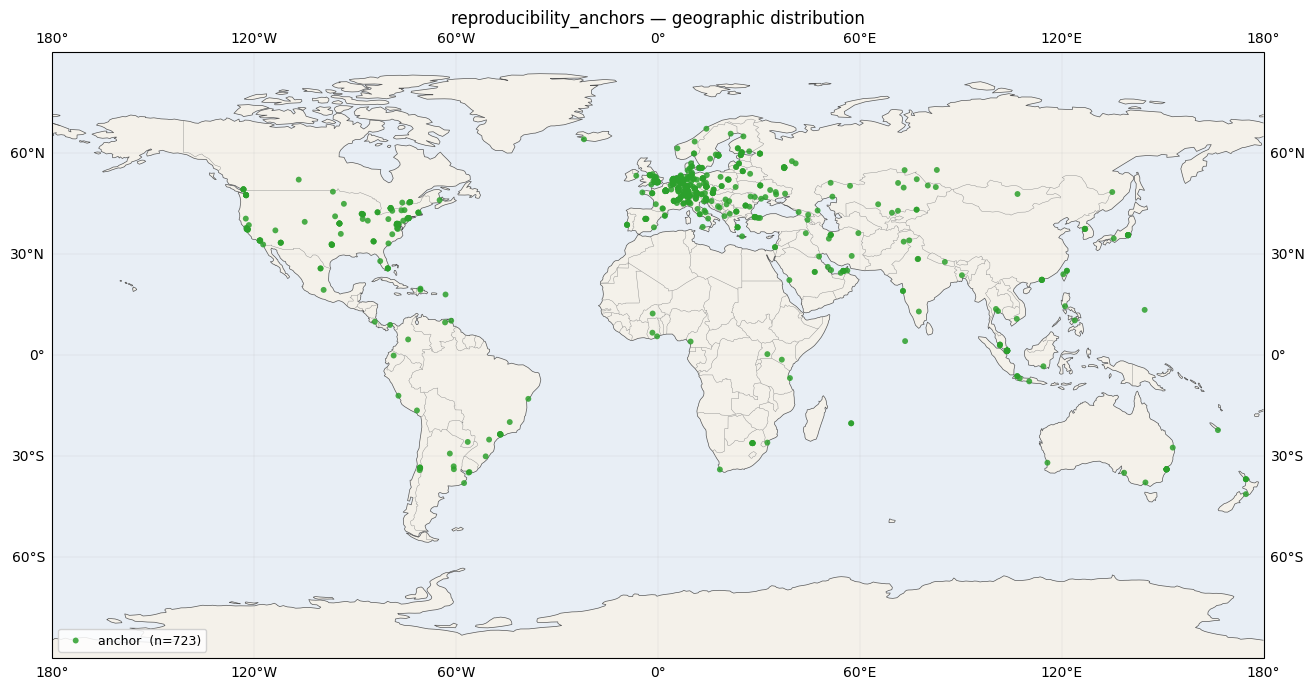

In [16]:
with open(ROOT / ANCHORS_PATH) as fh:
    raw_anchors = json.load(fh)

anchor_rows = []
for e in raw_anchors:
    geom = (e.get("geometry") or {}).get("coordinates")
    if not geom or len(geom) < 2:
        continue
    anchor_rows.append({
        "ip": e.get("address_v4"),
        "lat": float(geom[1]),
        "lon": float(geom[0]),
        "country": e.get("country_code"),
        "asn": e.get("asn_v4"),
    })
anchors_df = pd.DataFrame(anchor_rows)
print(f"anchors with coords: {len(anchors_df)}")

fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="#f4f1ea")
ax.add_feature(cfeature.OCEAN, facecolor="#e8eef5")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="#555")
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="#888")
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
ax.scatter(anchors_df["lon"], anchors_df["lat"], s=18, c="#2ca02c", alpha=0.85,
           edgecolors="none", label=f"anchor  (n={len(anchors_df)})",
           transform=ccrs.PlateCarree(), zorder=3)
ax.set_title("reproducibility_anchors — geographic distribution")
ax.legend(loc="lower left", fontsize=9, framealpha=0.85)
plt.tight_layout()
plt.show()